In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df_train = pd.read_csv('/content/drive/MyDrive/archive/fraudTrain.csv')

In [5]:
print(df_train.shape)
df_train.head()

(1296675, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [6]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [7]:
df_train.isnull().sum()

,0
Unnamed: 0,0
trans_date_trans_time,0
cc_num,0
merchant,0
category,0
amt,0
first,0
last,0
gender,0
street,0


In [8]:
df_train.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


Average transaction amount is $70.35, max value is 28,948 usd, fraud rate is 0.58%

In [9]:
df_train['category'].value_counts()

,count
category,
gas_transport,131659
grocery_pos,123638
home,123115
shopping_pos,116672
kids_pets,113035
shopping_net,97543
entertainment,94014
food_dining,91461
personal_care,90758


 14 transaction categories, gas_transport is most common (131,659), travel is least (40,507)

In [10]:
df_train['cc_num'].nunique()

983

983 unique credit card users in the dataset

In [11]:
print(df_train['trans_date_trans_time'].min())
print(df_train['trans_date_trans_time'].max())

2019-01-01 00:00:18
2020-06-21 12:13:37


In [12]:
df_train['is_fraud'].value_counts()

,count
is_fraud,
0,1289169
1,7506


In [13]:
user_spending = df_train.groupby('cc_num').agg({
    'amt': ['sum', 'mean', 'count']
}).round(2)
user_spending.columns = ['total_spent', 'avg_transaction', 'num_transactions']
user_spending.describe()

,total_spent,avg_transaction,num_transactions
count,983.000000,983.000000,983.000000
mean,92800.029400,110.994537,1319.099695
std,59584.778847,146.596010,812.235900
min,1348.530000,42.950000,7.000000
25%,43554.990000,61.015000,525.000000
50%,88514.240000,67.560000,1054.000000
75%,126784.210000,87.865000,2025.000000
max,296436.730000,948.820000,3123.000000


983 users, avg total spending $92,800, avg 1,319 transactions per user
Spending ranges from $1,348 to $296,436

In [14]:
user_category = df_train.groupby(['cc_num', 'category'])['amt'].sum().unstack(fill_value=0)
user_category.head()

category,entertainment,food_dining,gas_transport,grocery_net,grocery_pos,health_fitness,home,kids_pets,misc_net,misc_pos,personal_care,shopping_net,shopping_pos,travel
cc_num,,,,,,,,,,,,,,
60416207185,5327.22,2353.95,13221.64,2670.81,14646.56,4241.94,7604.69,6671.92,3020.70,4838.97,5629.21,3515.72,10893.96,406.18
60422928733,6857.47,9870.48,10121.71,2407.72,14740.06,4687.39,10213.69,11821.96,4037.81,6038.31,6036.51,9475.63,8832.35,499.11
60423098130,2290.18,2248.67,3641.47,37.27,5335.87,1708.76,1854.30,2741.89,1471.80,1141.46,2061.65,5262.95,1629.83,27247.53
60427851591,2985.29,1528.00,2081.52,1142.46,7818.85,2550.97,4798.08,2242.31,4213.20,1635.23,1553.62,9500.07,6355.39,10724.62
60487002085,1495.84,1884.46,3637.95,1009.63,4028.14,2270.87,2191.04,2641.24,192.06,2900.79,817.60,557.37,1444.32,88.80


In [15]:

df_train['datetime'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['hour'] = df_train['datetime'].dt.hour
df_train['day_of_week'] = df_train['datetime'].dt.dayofweek
df_train['month'] = df_train['datetime'].dt.month

print(df_train['hour'].value_counts().sort_index())

hour
0     42502
1     42869
2     42656
3     42769
4     41863
5     42171
6     42300
7     42203
8     42505
9     42185
10    42271
11    42082
12    65257
13    65314
14    64885
15    65391
16    65726
17    65450
18    66051
19    65508
20    65098
21    65533
22    66982
23    67104
Name: count, dtype: int64


More transactions in afternoon/evening (12pm-11pm: ~65k each) vs morning (12am-11am: ~42k each)

Peak hours: 10pm-11pm (~67k transactions)

In [16]:
df_train.groupby('is_fraud')['amt'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,67.667110,154.007971,1.00,9.6100,47.280,82.540,28948.90
1,7506.0,531.320092,390.560070,1.06,245.6625,396.505,900.875,1376.04


Fraud transactions avg 531 dollars vs normal avg 68 dollars - frauds are 8x larger!
Fraud max 1,376 dollars vs normal max 28,948 dollars - normal has higher max but fraud avg is way higher

## Phase 2: Data Cleaning

In [17]:
duplicates = df_train.duplicated().sum()
print(f"Exact duplicates found: {duplicates:,}")

Exact duplicates found: 0


No duplicates have been found.

In [18]:
if duplicates > 0:
    print(f"Removing {duplicates} duplicate rows...")
    df_train = df_train.drop_duplicates()
    print(f"Dataset after cleaning: {len(df_train):,} rows")
else:
    print("No duplicates - data is clean")

No duplicates - data is clean


In [19]:
Q1, Q3 = df_train['amt'].quantile([0.25, 0.75])
IQR = Q3 - Q1
upper_bound = Q3 + 3 * IQR

outliers = df_train[df_train['amt'] > upper_bound]

print(f"Outliers (amounts > ${upper_bound:.2f}): {len(outliers):,} ({len(outliers)/len(df_train)*100:.2f}%)")

fraud_in_outliers = outliers['is_fraud'].sum()
print(f"Frauds among outliers: {fraud_in_outliers} ({fraud_in_outliers/len(outliers)*100:.1f}%)")
print("Keeping outliers - useful for fraud detection")

Outliers (amounts > $303.61): 29,813 (2.30%)
Frauds among outliers: 4810 (16.1%)
Keeping outliers - useful for fraud detection


In [20]:
print("\nData type validation:")
print(df_train.dtypes)


Data type validation:
Unnamed: 0                        int64
trans_date_trans_time            object
cc_num                            int64
merchant                         object
category                         object
amt                             float64
first                            object
last                             object
gender                           object
street                           object
city                             object
state                            object
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                              object
trans_num                        object
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
datetime                 datetime64[ns]
hour             

In [21]:
categorical_cols = ['category', 'gender', 'city', 'state', 'job', 'merchant']
for col in categorical_cols:
    if col in df_train.columns and df_train[col].dtype == 'object':
        df_train[col] = df_train[col].astype('category')

print(f"Memory usage: {df_train.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Memory usage: 626.4 MB


In [22]:
negative_amt = df_train[df_train['amt'] < 0]
zero_amt = df_train[df_train['amt'] == 0]
print(f"  Negative amounts: {len(negative_amt)}")
print(f"  Zero amounts: {len(zero_amt)}")

if len(zero_amt) > 0:
    df_train = df_train[df_train['amt'] > 0]
    print(f"  Removed {len(zero_amt)} zero-amount transactions")

invalid_lat = df_train[(df_train['lat'] < -90) | (df_train['lat'] > 90)]
invalid_long = df_train[(df_train['long'] < -180) | (df_train['long'] > 180)]
print(f"  Invalid latitudes: {len(invalid_lat)}")
print(f"  Invalid longitudes: {len(invalid_long)}")

print("  All value ranges valid")

  Negative amounts: 0
  Zero amounts: 0
  Invalid latitudes: 0
  Invalid longitudes: 0
  All value ranges valid


In [23]:
print("\nDate range validation:")
print(f"  First transaction: {df_train['datetime'].min()}")
print(f"  Last transaction: {df_train['datetime'].max()}")

duration = (df_train['datetime'].max() - df_train['datetime'].min()).days
print(f"  Duration: {duration} days")

df_train = df_train.sort_values('datetime').reset_index(drop=True)
print("  Sorted by date")


Date range validation:
  First transaction: 2019-01-01 00:00:18
  Last transaction: 2020-06-21 12:13:37
  Duration: 537 days
  Sorted by date


In [24]:
df_train.to_csv('/content/drive/MyDrive/archive/fraudTrain_cleaned.csv', index=False)

Data Cleaning Summary

In [25]:
print(f"Original dataset: 1,296,675 rows")
print(f"Cleaned dataset: {len(df_train):,} rows × {df_train.shape[1]} columns")
print(f"Duplicates removed: {duplicates}")
print(f"Outliers detected: {len(outliers):,} (kept)")
print(f"Date range: {df_train['datetime'].min().date()} to {df_train['datetime'].max().date()}")

Original dataset: 1,296,675 rows
Cleaned dataset: 1,296,675 rows × 27 columns
Duplicates removed: 0
Outliers detected: 29,813 (kept)
Date range: 2019-01-01 to 2020-06-21


## Phase 3: Exploratory Data Analysis (EDA)

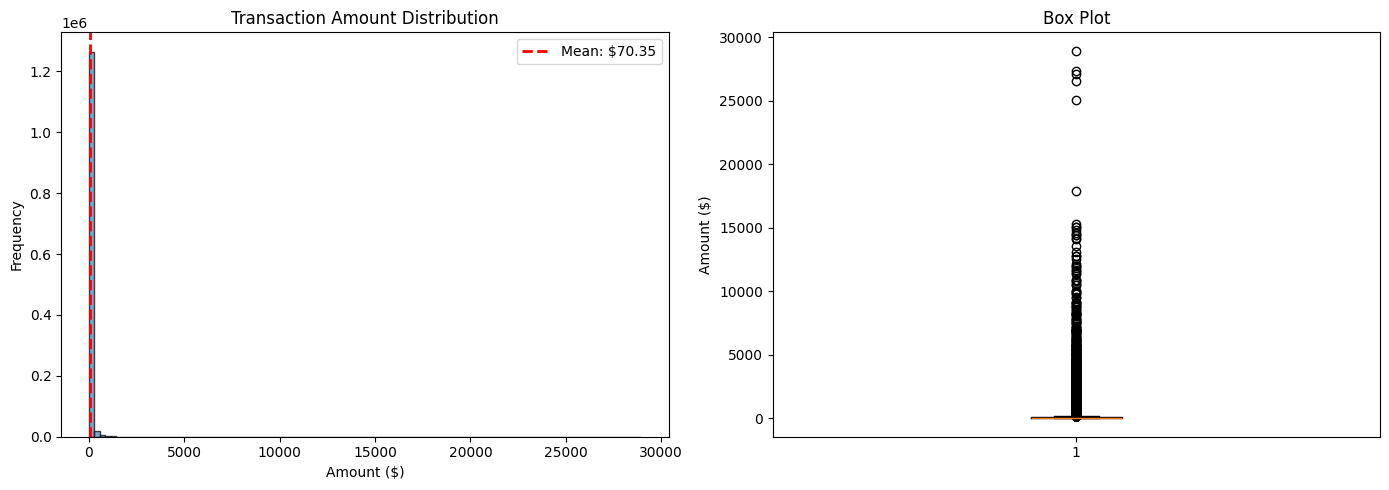

Mean: $70.35, Median: $47.52, Std: $160.32


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_train['amt'], bins=100, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(df_train['amt'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Mean: ${df_train['amt'].mean():.2f}")
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Transaction Amount Distribution')
axes[0].legend()

axes[1].boxplot(df_train['amt'])
axes[1].set_ylabel('Amount ($)')
axes[1].set_title('Box Plot')

plt.tight_layout()
plt.show()
print(f"Mean: ${df_train['amt'].mean():.2f}, Median: ${df_train['amt'].median():.2f}, Std: ${df_train['amt'].std():.2f}")

In [27]:
category_stats = df_train.groupby('category')['amt'].agg(['count', 'sum', 'mean']).round(2)
category_stats.columns = ['transactions', 'total_spent', 'avg_amount']
category_stats = category_stats.sort_values('total_spent', ascending=False)

print("Top categories by spending:")
category_stats

Top categories by spending:


/tmp/ipykernel_656/3997235174.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  category_stats = df_train.groupby('category')['amt'].agg(['count', 'sum', 'mean']).round(2)


,transactions,total_spent,avg_amount
category,,,
grocery_pos,123638,14460822.38,116.96
shopping_pos,116672,9307993.61,79.78
shopping_net,97543,8625149.68,88.42
gas_transport,131659,8351732.29,63.43
home,123115,7173928.11,58.27
kids_pets,113035,6503680.16,57.54
entertainment,94014,6036678.56,64.21
misc_net,63287,5117709.26,80.87
misc_pos,79655,5009582.50,62.89


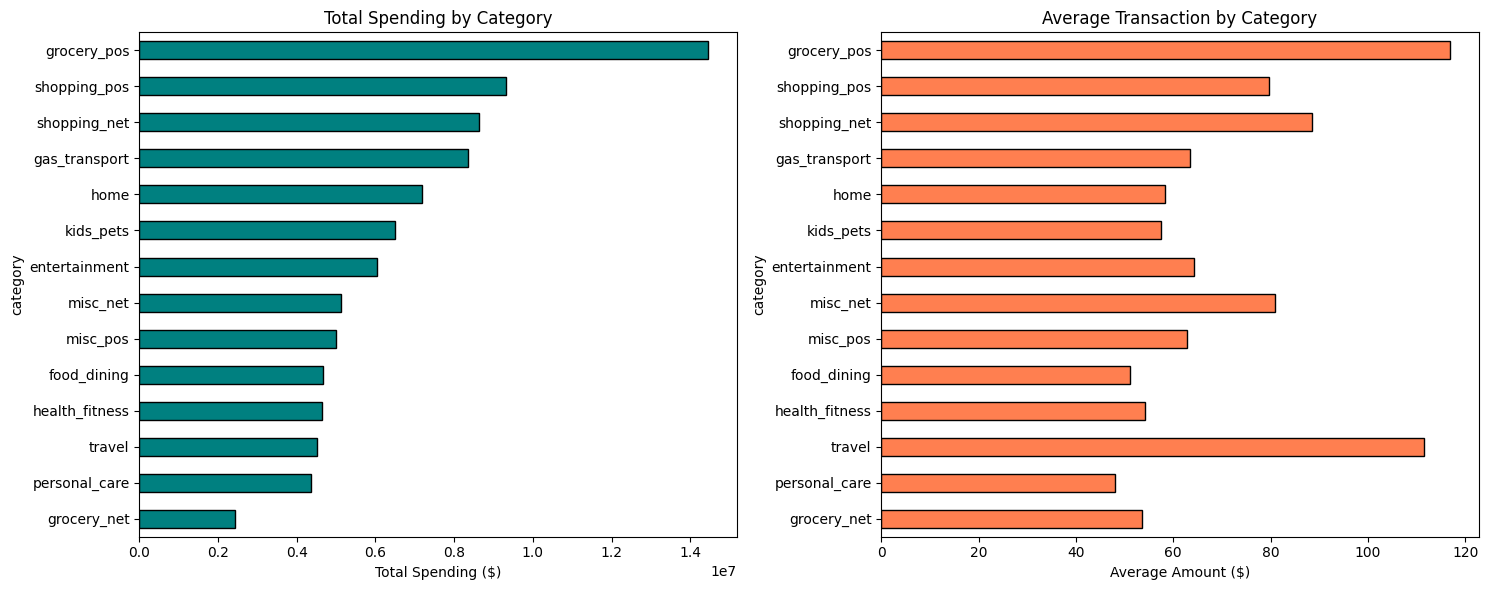

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

category_stats['total_spent'].plot(kind='barh', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_xlabel('Total Spending ($)')
axes[0].set_title('Total Spending by Category')
axes[0].invert_yaxis()

category_stats['avg_amount'].plot(kind='barh', ax=axes[1], color='coral', edgecolor='black')
axes[1].set_xlabel('Average Amount ($)')
axes[1].set_title('Average Transaction by Category')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [29]:
hourly_stats = df_train.groupby('hour')['amt'].agg(['count', 'sum', 'mean']).round(2)
hourly_stats.columns = ['transactions', 'total_spent', 'avg_amount']
print("Peak hours:")
hourly_stats.sort_values('transactions', ascending=False).head(5)

Peak hours:


,transactions,total_spent,avg_amount
hour,,,
23,67104,5308144.32,79.10
22,66982,5408217.79,80.74
18,66051,4152468.36,62.87
16,65726,4198648.35,63.88
21,65533,4131913.83,63.05


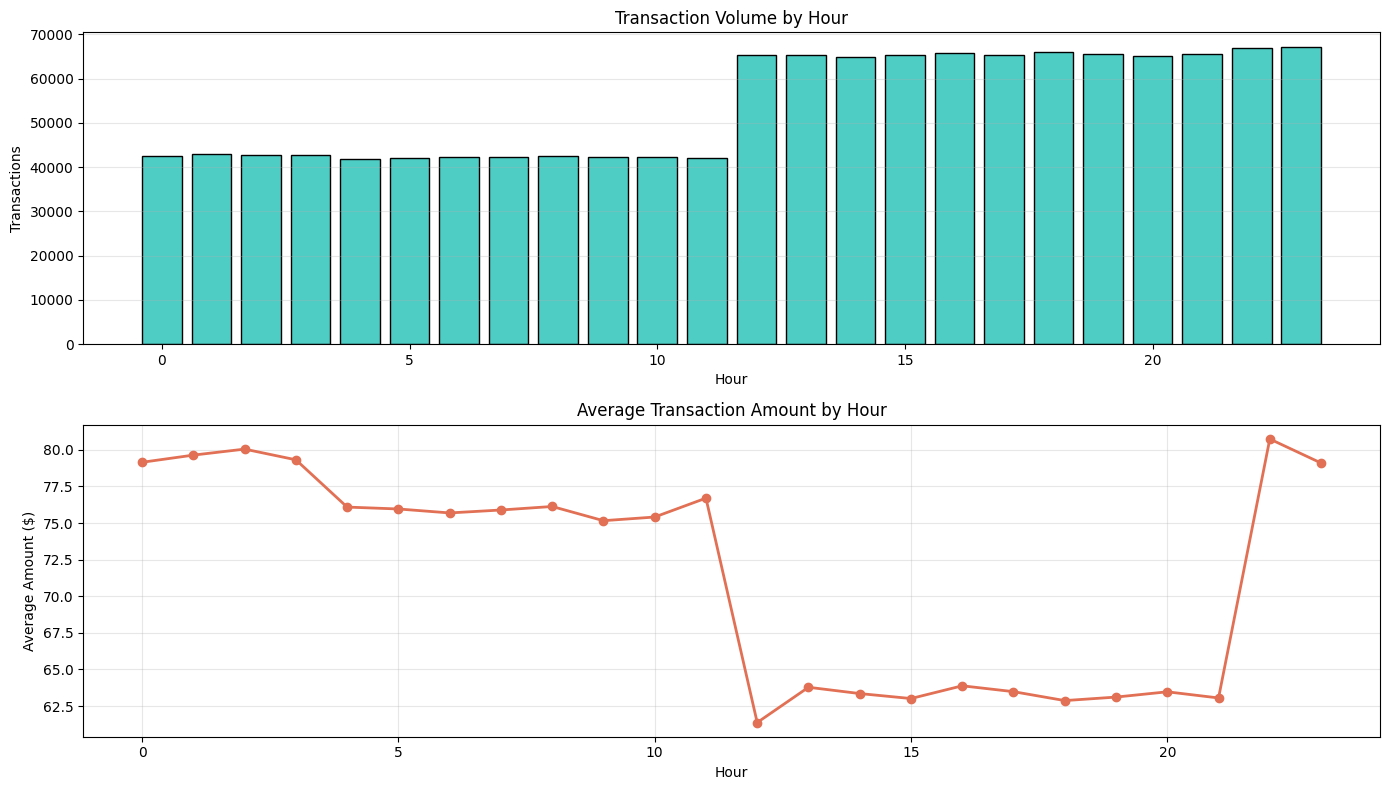

Peak hours: 10pm-11pm (~67k transactions each)
Morning (12am-11am): ~42k transactions each


In [30]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].bar(hourly_stats.index, hourly_stats['transactions'], color='#4ECDC4', edgecolor='black')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Transactions')
axes[0].set_title('Transaction Volume by Hour')
axes[0].grid(axis='y', alpha=0.3)
axes[1].plot(hourly_stats.index, hourly_stats['avg_amount'], marker='o', linewidth=2,
             color='#E17055', markersize=6)
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Average Amount ($)')
axes[1].set_title('Average Transaction Amount by Hour')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Peak hours: 10pm-11pm (~67k transactions each)")
print(f"Morning (12am-11am): ~42k transactions each")

In [31]:
dow_stats = df_train.groupby('day_of_week')['amt'].agg(['count', 'sum', 'mean']).round(2)
dow_stats.columns = ['transactions', 'total_spent', 'avg_amount']
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_stats.index = dow_names
dow_stats

,transactions,total_spent,avg_amount
Mon,254282,17847845.06,70.19
Tue,160227,11244617.84,70.18
Wed,131073,9249541.86,70.57
Thu,147285,10556820.40,71.68
Fri,152272,10760969.63,70.67
Sat,200957,14183344.69,70.58
Sun,250579,17379289.42,69.36


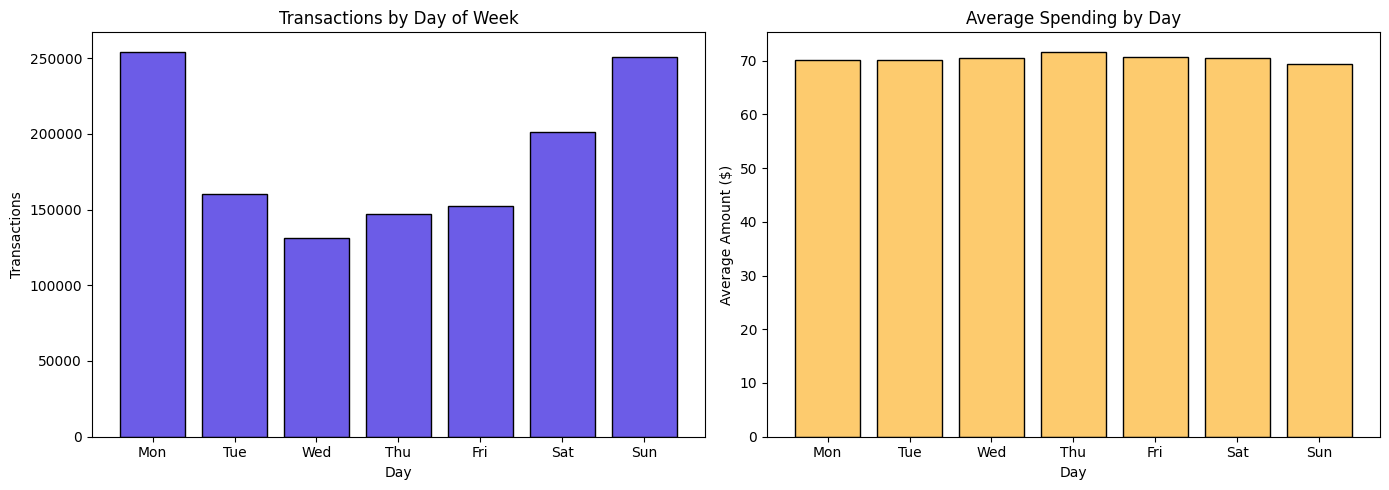

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dow_stats.index, dow_stats['transactions'], color='#6C5CE7', edgecolor='black')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Transactions')
axes[0].set_title('Transactions by Day of Week')

axes[1].bar(dow_stats.index, dow_stats['avg_amount'], color='#FDCB6E', edgecolor='black')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Average Amount ($)')
axes[1].set_title('Average Spending by Day')

plt.tight_layout()
plt.show()

In [33]:
df_train['is_weekend'] = df_train['day_of_week'].isin([5, 6]).astype(int)
weekend_stats = df_train.groupby('is_weekend')['amt'].agg(['count', 'mean', 'sum']).round(2)
weekend_stats.index = ['Weekday', 'Weekend']
weekend_stats.columns = ['transactions', 'avg_amount', 'total_spent']
weekend_stats

,transactions,avg_amount,total_spent
Weekday,845139,70.59,59659794.79
Weekend,451536,69.90,31562634.11


In [34]:
def categorize_time(hour):
    if 6 <= hour < 12: return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 21: return 'Evening'
    else: return 'Night'

df_train['time_of_day'] = df_train['hour'].apply(categorize_time)
time_stats = df_train.groupby('time_of_day')['amt'].agg(['count', 'sum', 'mean']).round(2)
time_stats.columns = ['transactions', 'total_spent', 'avg_amount']
time_stats = time_stats.reindex(['Morning', 'Afternoon', 'Evening', 'Night'])
time_stats

,transactions,total_spent,avg_amount
time_of_day,,,
Morning,253546,19226988.38,75.83
Afternoon,326573,20600823.24,63.08
Evening,262107,16572726.36,63.23
Night,454449,34821890.92,76.62


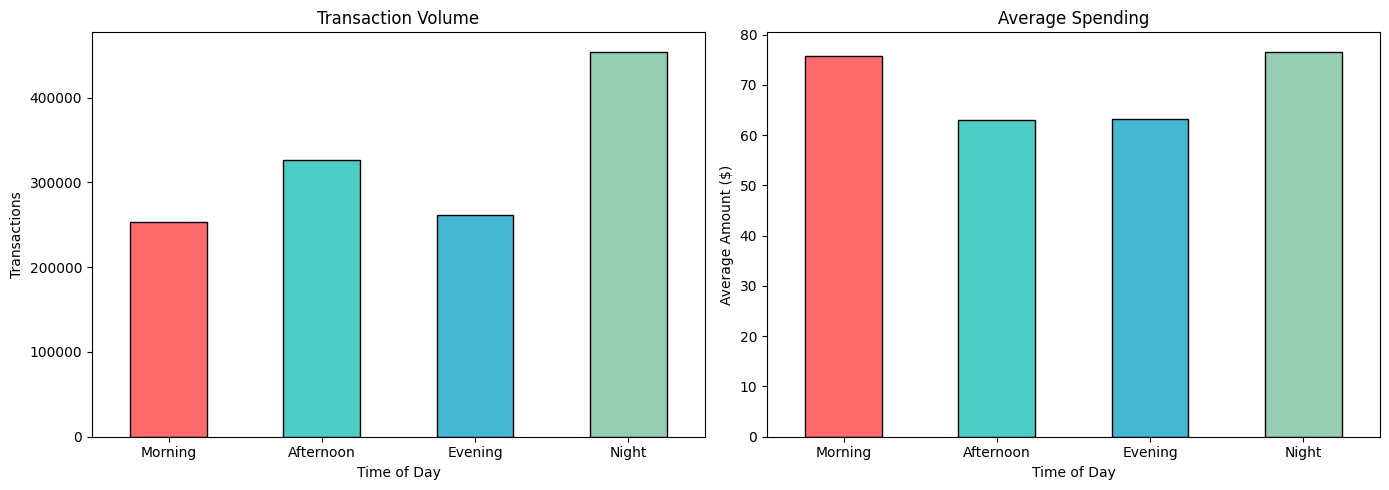

Afternoon/Evening have most activity (~65k each)


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

time_stats['transactions'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='black')
axes[0].set_xlabel('Time of Day')
axes[0].set_ylabel('Transactions')
axes[0].set_title('Transaction Volume')
axes[0].tick_params(axis='x', rotation=0)

time_stats['avg_amount'].plot(kind='bar', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Average Amount ($)')
axes[1].set_title('Average Spending')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()
print("Afternoon/Evening have most activity (~65k each)")

In [36]:
state_stats = df_train.groupby('state').agg({
    'amt': ['count', 'sum', 'mean'],
    'cc_num': 'nunique'
}).round(2)
state_stats.columns = ['transactions', 'total_spent', 'avg_amount', 'users']
state_stats = state_stats.sort_values('total_spent', ascending=False).head(10)

print("Top 10 states by total spending:")
state_stats

Top 10 states by total spending:


/tmp/ipykernel_656/3646332909.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  state_stats = df_train.groupby('state').agg({


,transactions,total_spent,avg_amount,users
state,,,,
TX,94876,6800917.53,71.68,66
NY,83501,6006499.03,71.93,71
PA,79847,5771009.53,72.28,58
CA,56360,4138078.51,73.42,45
OH,46480,3396146.66,73.07,39
MI,46154,3282724.96,71.13,32
FL,42671,3155191.63,73.94,35
IL,43252,3011891.30,69.64,33
AL,40989,2682717.10,65.45,28


In [37]:
monthly_stats = df_train.groupby('month')['amt'].agg(['count', 'sum', 'mean']).round(2)
monthly_stats.columns = ['transactions', 'total_spent', 'avg_amount']

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_stats.index = month_names
monthly_stats

,transactions,total_spent,avg_amount
Jan,104727,7422814.52,70.88
Feb,97657,6974606.28,71.42
Mar,143789,10190002.48,70.87
Apr,134970,9452834.36,70.04
May,146875,10304940.14,70.16
Jun,143811,10143382.17,70.53
Jul,86596,6044026.74,69.80
Aug,87359,6047288.65,69.22
Sep,70652,4949834.42,70.06
Oct,68758,4851267.37,70.56


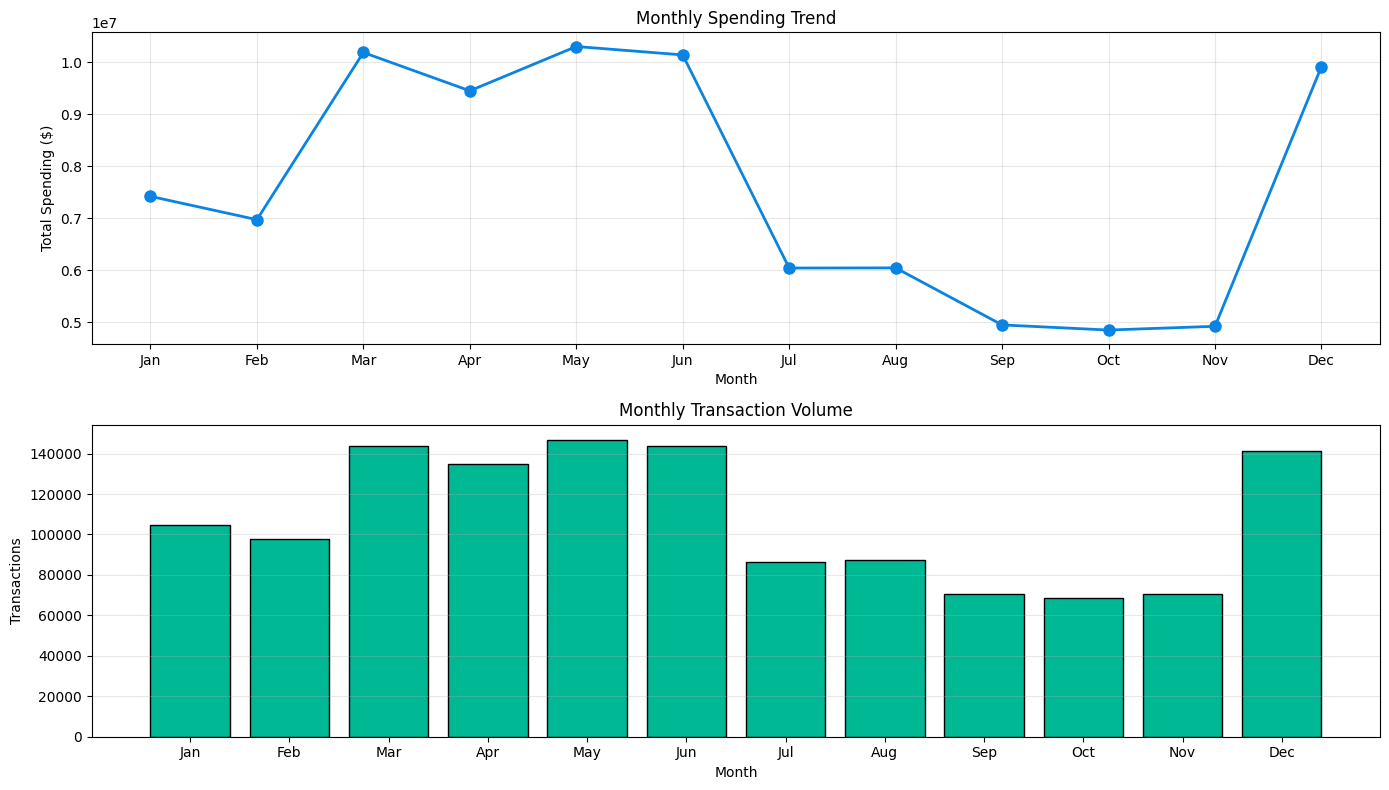

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(monthly_stats.index, monthly_stats['total_spent'],
             marker='o', linewidth=2, color='#0984E3', markersize=8)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Spending ($)')
axes[0].set_title('Monthly Spending Trend')
axes[0].grid(True, alpha=0.3)

axes[1].bar(monthly_stats.index, monthly_stats['transactions'],
            color='#00B894', edgecolor='black')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Transactions')
axes[1].set_title('Monthly Transaction Volume')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
fraud_stats = df_train.groupby('is_fraud')['amt'].agg(['count', 'mean', 'sum', 'std', 'min', 'max']).round(2)
fraud_stats.index = ['Normal', 'Fraud']
fraud_stats.columns = ['count', 'avg', 'total', 'std', 'min', 'max']
fraud_stats

,count,avg,total,std,min,max
Normal,1289169,67.67,87234340.29,154.01,1.00,28948.90
Fraud,7506,531.32,3988088.61,390.56,1.06,1376.04


/tmp/ipykernel_656/1329612349.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_cat = df_train.groupby(['category', 'is_fraud']).size().unstack(fill_value=0)


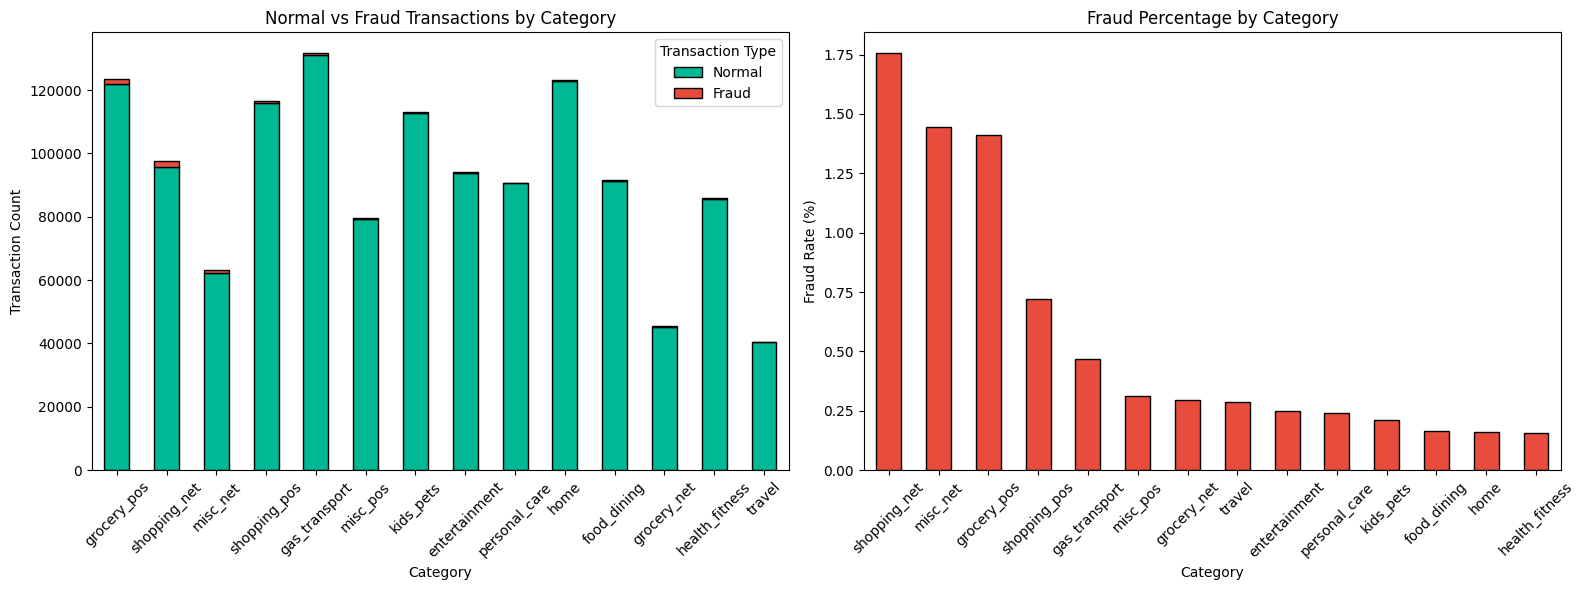

Highest fraud rate: shopping_net (1.76%)


In [40]:
fraud_by_cat = df_train.groupby(['category', 'is_fraud']).size().unstack(fill_value=0)
fraud_by_cat.columns = ['Normal', 'Fraud']
fraud_by_cat = fraud_by_cat.sort_values('Fraud', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fraud_by_cat.plot(kind='bar', stacked=True, ax=axes[0], color=['#00B894', '#E74C3C'], edgecolor='black')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Normal vs Fraud Transactions by Category')
axes[0].legend(title='Transaction Type')
axes[0].tick_params(axis='x', rotation=45)

fraud_pct = (fraud_by_cat['Fraud'] / fraud_by_cat.sum(axis=1) * 100).sort_values(ascending=False)
fraud_pct.plot(kind='bar', ax=axes[1], color='#E74C3C', edgecolor='black')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Percentage by Category')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"Highest fraud rate: {fraud_pct.index[0]} ({fraud_pct.values[0]:.2f}%)")

Fraud transactions avg 531 dollars vs normal avg 68 dollars - frauds are 8 times higher. Fraud max 1,376 dollars vs normal max 28,948 dollars - normal has higher max but fraud average is way higher.

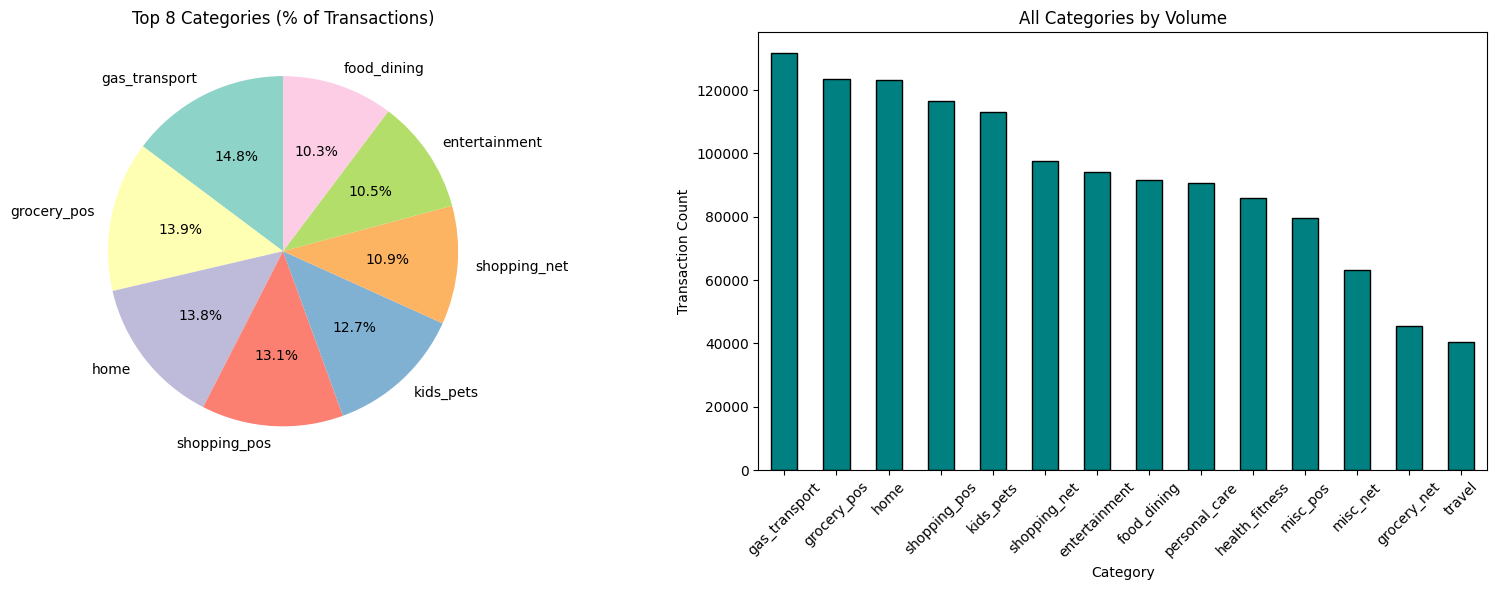

In [41]:
category_counts = df_train['category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

category_counts.head(8).plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90,
                              colors=plt.cm.Set3.colors)
axes[0].set_ylabel('')
axes[0].set_title('Top 8 Categories (% of Transactions)')

category_counts.plot(kind='bar', ax=axes[1], color='teal', edgecolor='black')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Transaction Count')
axes[1].set_title('All Categories by Volume')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

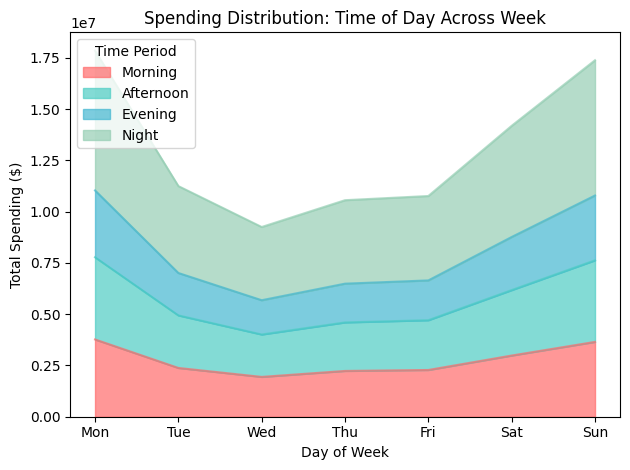

In [42]:
time_dow = df_train.groupby(['day_of_week', 'time_of_day'])['amt'].sum().unstack(fill_value=0)
time_dow = time_dow[['Morning', 'Afternoon', 'Evening', 'Night']]
time_dow.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.figure(figsize=(14, 6))
time_dow.plot(kind='area', stacked=True, alpha=0.7,
              color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'])
plt.xlabel('Day of Week')
plt.ylabel('Total Spending ($)')
plt.title('Spending Distribution: Time of Day Across Week')
plt.legend(title='Time Period', loc='upper left')
plt.tight_layout()
plt.show()


# ============================================================
# PHASE 3 CONTINUED - Remaining EDA
# ============================================================

1. USER-LEVEL SPENDING PROFILE DISTRIBUTION

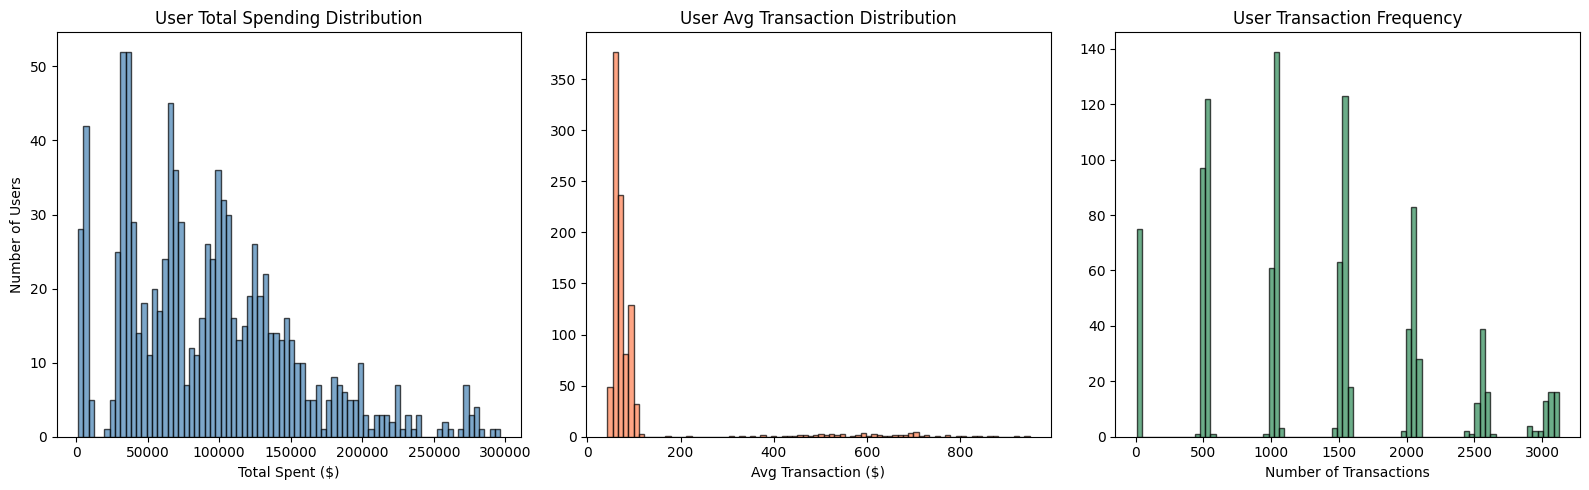

         total_spent  avg_transaction  num_transactions  unique_categories  \
count     983.000000       983.000000        983.000000         983.000000   
mean    92800.029400       110.994537       1319.099695          13.314344   
std     59584.778847       146.596010        812.235900           2.406260   
min      1348.530000        42.950000          7.000000           2.000000   
25%     43554.990000        61.015000        525.000000          14.000000   
50%     88514.240000        67.560000       1054.000000          14.000000   
75%    126784.210000        87.865000       2025.000000          14.000000   
max    296436.730000       948.820000       3123.000000          14.000000   

       std_transaction  
count       983.000000  
mean        159.113561  
std         104.351019  
min          60.250000  
25%         104.360000  
50%         123.940000  
75%         162.120000  
max        1202.990000  


In [43]:
user_profile = df_train.groupby('cc_num').agg(
    total_spent=('amt', 'sum'),
    avg_transaction=('amt', 'mean'),
    num_transactions=('amt', 'count'),
    unique_categories=('category', 'nunique'),
    std_transaction=('amt', 'std')
).fillna(0).round(2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(user_profile['total_spent'], bins=80, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('User Total Spending Distribution')
axes[0].set_xlabel('Total Spent ($)')
axes[0].set_ylabel('Number of Users')

axes[1].hist(user_profile['avg_transaction'], bins=80, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('User Avg Transaction Distribution')
axes[1].set_xlabel('Avg Transaction ($)')

axes[2].hist(user_profile['num_transactions'], bins=80, color='seagreen', edgecolor='black', alpha=0.7)
axes[2].set_title('User Transaction Frequency')
axes[2].set_xlabel('Number of Transactions')

plt.tight_layout()
plt.show()

print(user_profile.describe())

#  2. CATEGORY SPEND MATRIX (per user) + CORRELATION HEATMAP ─
# Directly feeds into clustering — shows how categories relate to each other

/tmp/ipykernel_656/1643135295.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_category = df_train.groupby(['cc_num', 'category'])['amt'].sum().unstack(fill_value=0)


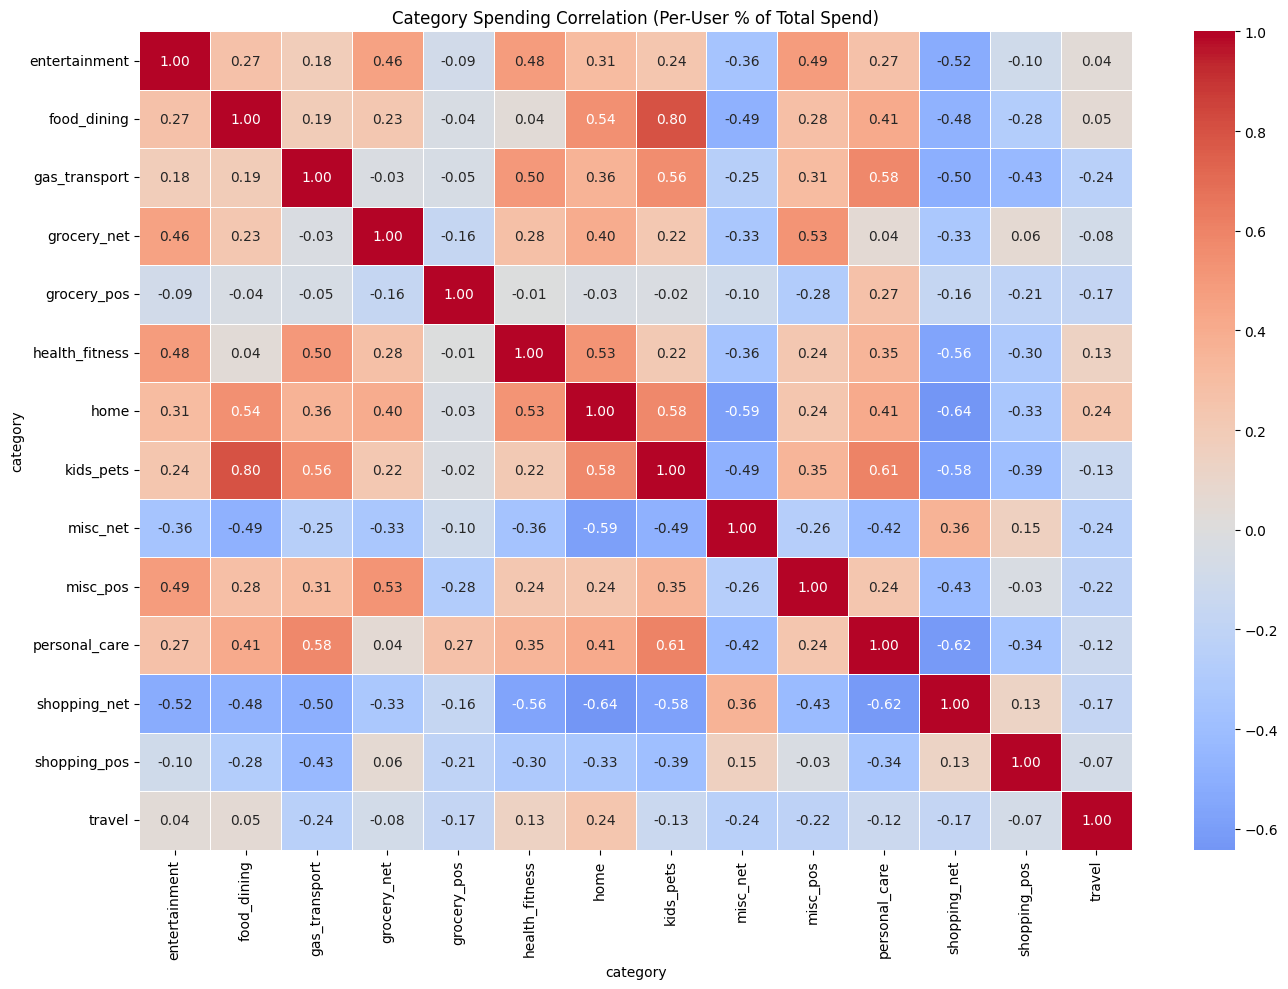

In [44]:
user_category = df_train.groupby(['cc_num', 'category'])['amt'].sum().unstack(fill_value=0)

# Normalize per user (% of their total spend per category)
user_category_pct = user_category.div(user_category.sum(axis=1), axis=0).round(4)

plt.figure(figsize=(14, 10))
sns.heatmap(
    user_category_pct.corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Category Spending Correlation (Per-User % of Total Spend)')
plt.tight_layout()
plt.show()

#  3. FRAUD ANALYSIS — AMOUNT, TIME & USER LEVEL
# Your anomaly detection (Isolation Forest) and fraud classifier need this context

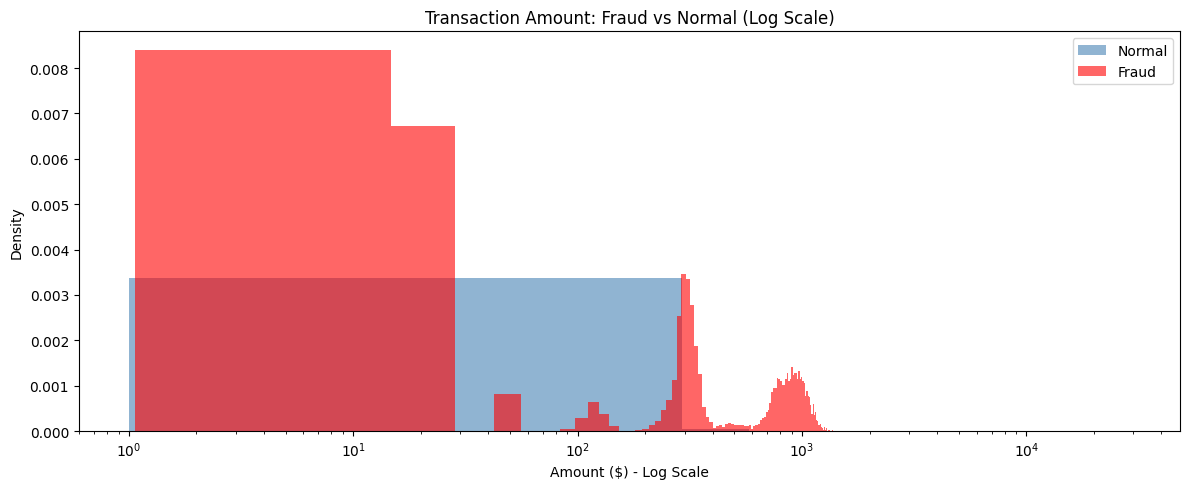

In [45]:
#  3a. Amount distribution: fraud vs normal (log scale)
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(df_train[df_train['is_fraud'] == 0]['amt'], bins=100,
        alpha=0.6, color='steelblue', label='Normal', density=True)
ax.hist(df_train[df_train['is_fraud'] == 1]['amt'], bins=100,
        alpha=0.6, color='red', label='Fraud', density=True)
ax.set_xscale('log')
ax.set_xlabel('Amount ($) - Log Scale')
ax.set_ylabel('Density')
ax.set_title('Transaction Amount: Fraud vs Normal (Log Scale)')
ax.legend()
plt.tight_layout()
plt.show()


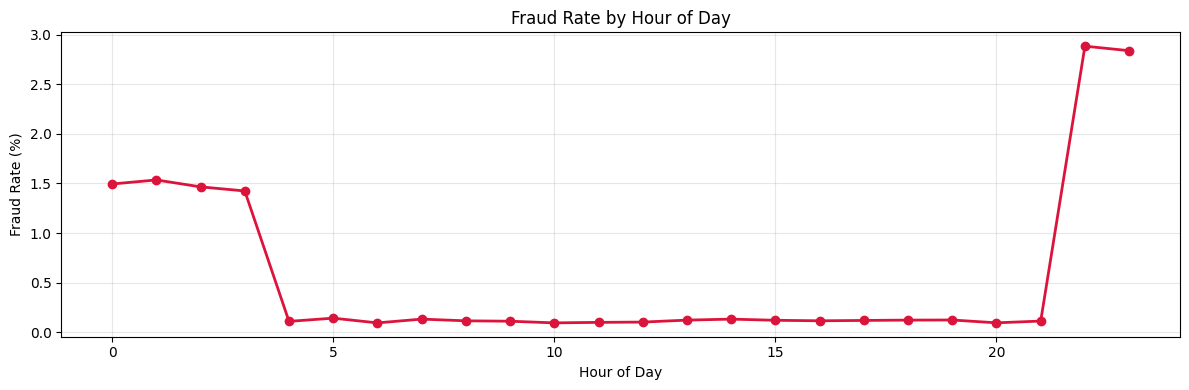

In [46]:
#  3b. Fraud rate by hour
fraud_by_hour = df_train.groupby('hour')['is_fraud'].mean() * 100
plt.figure(figsize=(12, 4))
plt.plot(fraud_by_hour.index, fraud_by_hour.values, marker='o', color='crimson', linewidth=2)
plt.xlabel('Hour of Day')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Hour of Day')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

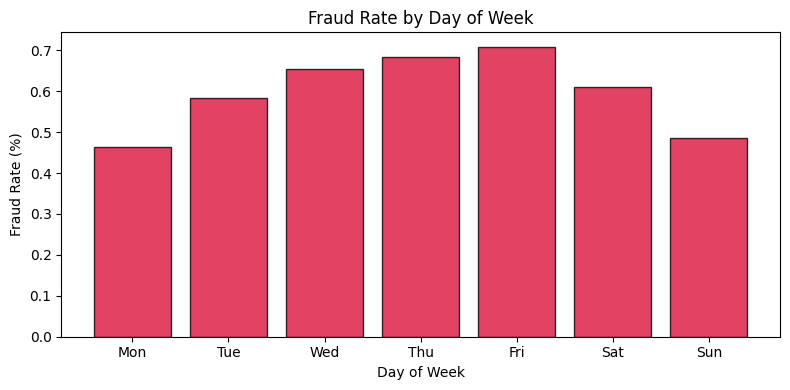

In [47]:
#  3c. Fraud rate by day of week
fraud_by_dow = df_train.groupby('day_of_week')['is_fraud'].mean() * 100
fraud_by_dow.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.figure(figsize=(8, 4))
plt.bar(fraud_by_dow.index, fraud_by_dow.values, color='crimson', edgecolor='black', alpha=0.8)
plt.xlabel('Day of Week')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Day of Week')
plt.tight_layout()
plt.show()

In [48]:
#  3d. Users with highest fraud exposure
fraud_user = df_train.groupby('cc_num').agg(
    total_transactions=('is_fraud', 'count'),
    fraud_count=('is_fraud', 'sum')
)
fraud_user['fraud_rate'] = (fraud_user['fraud_count'] / fraud_user['total_transactions'] * 100).round(2)
print("\nUsers with highest fraud exposure:")
print(fraud_user[fraud_user['fraud_count'] > 0].sort_values('fraud_rate', ascending=False).head(10))



Users with highest fraud exposure:
                     total_transactions  fraud_count  fraud_rate
cc_num                                                          
501818133297                          8            8       100.0
501851115094                         15           15       100.0
3542826960473004                     10           10       100.0
3543885983111461                     11           11       100.0
3545578418030657                      7            7       100.0
3528040995648998                     11           11       100.0
3529788038921264                     10           10       100.0
3535211949888417                      8            8       100.0
676179782773                         11           11       100.0
4257110907449569602                  10           10       100.0


# 4. CLASS IMBALANCE CHECK
# Critical — your models will need SMOTE or class_weight handling

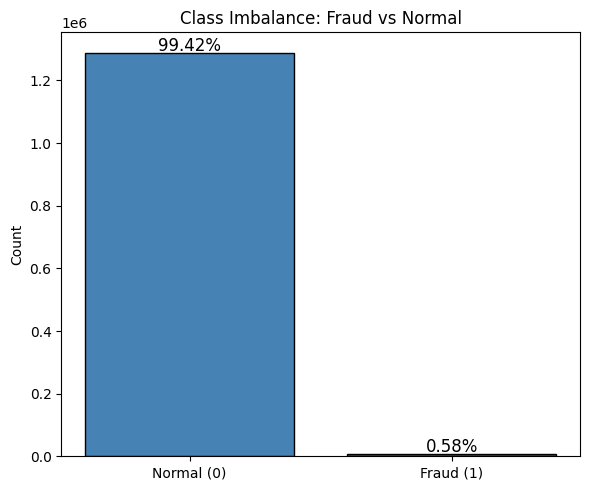


Imbalance ratio — Normal:Fraud = 1,289,169 : 7,506
Fraud is 0.58% of all transactions
→ Will need class_weight='balanced' or SMOTE in modeling phase


In [49]:
fraud_counts = df_train['is_fraud'].value_counts()
fraud_pct = df_train['is_fraud'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(['Normal (0)', 'Fraud (1)'], fraud_counts.values,
               color=['steelblue', 'crimson'], edgecolor='black')
for bar, pct in zip(bars, fraud_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{pct:.2f}%', ha='center', fontsize=12)
ax.set_title('Class Imbalance: Fraud vs Normal')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f"\nImbalance ratio — Normal:Fraud = {fraud_counts[0]:,} : {fraud_counts[1]:,}")
print(f"Fraud is {fraud_pct[1]:.2f}% of all transactions")
print("→ Will need class_weight='balanced' or SMOTE in modeling phase")


# 5. FEATURE CORRELATION WITH FRAUD
# Shows which numeric features are most useful for your ML models


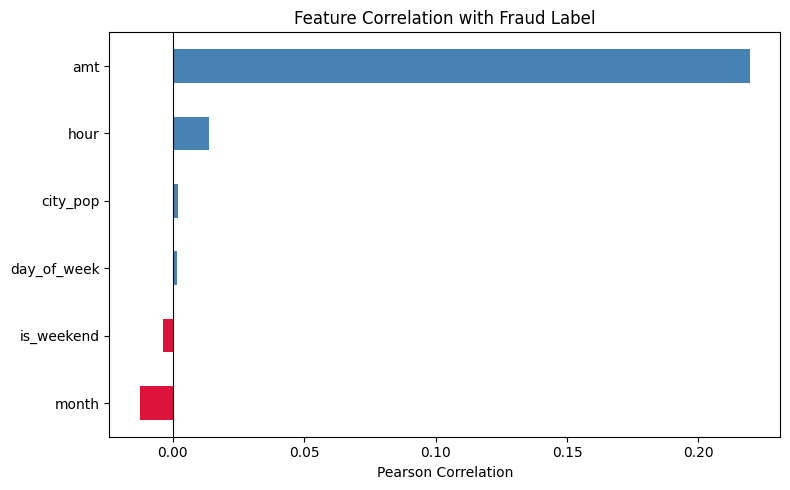

In [50]:
numeric_features = ['amt', 'hour', 'day_of_week', 'month', 'city_pop', 'is_weekend']
corr_with_fraud = df_train[numeric_features + ['is_fraud']].corr()['is_fraud'].drop('is_fraud').sort_values()

plt.figure(figsize=(8, 5))
corr_with_fraud.plot(kind='barh', color=['crimson' if x < 0 else 'steelblue' for x in corr_with_fraud])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Fraud Label')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()